In [8]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import warnings
warnings.filterwarnings(action = 'ignore')

# <font color='red'>ch01_허깅페이스</font>
- Transformers 라이브러리 내 pipeline()함수
- INference API : 발부 받은 key를 사용
## 1. 텍스트 기반 감정 분석(긍정/부정)

In [3]:
from transformers import pipeline

In [5]:
classifier = pipeline(task = 'text-classification',
                     model="distilbert-base-uncased-finetuned-sst-2-english")
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [8]:
classifier('이 영화는 정말 최고였어요, 감동적이고 연기가 대단해요')

[{'label': 'POSITIVE', 'score': 0.9054417610168457}]

In [9]:
result = classifier(["I've been waiting for a HuggingFace course my whole life.",
                     "I hate this so much!"])
[r.get('label') for r in result]

['POSITIVE', 'NEGATIVE']

## 2. 제로-샷 분류(zero-shot-classification)
- 비지도학습(군집분류)

In [16]:
classifier = pipeline(task = 'sentiment-analysis',
                     model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use cpu


In [17]:
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [19]:
classifier = pipeline(task = 'zero-shot-classification',
                     model = 'facebook/bart-large-mnli')
classifier("I have a prblem with my iphone that needs to be resolved asap!!",
          candidate_labels =['phone','urgent','tablet','computer'])

Device set to use cpu


{'sequence': 'I have a prblem with my iphone that needs to be resolved asap!!',
 'labels': ['phone', 'urgent', 'computer', 'tablet'],
 'scores': [0.5059282183647156,
  0.4734128415584564,
  0.01765393279492855,
  0.003004995407536626]}

## 3. text 생성

In [20]:
generator = pipeline(task = 'text-generation',
                    model = "gpt2") # 허깅페이스 gpt2까지

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [22]:
generator("In this course. We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': 'In this course. We will teach you how to write code with HTML, CSS, JavaScript and jQuery.\n\nIf you want to be a master of your craft in JavaScript, check out our JavaScript Tutorials.\n\nWhat We\'re Building\n\nIf you missed the recent announcement that we were going to release JavaScript 5.0, now is the time to get to work.\n\nWe have released a small rewrite of the codebase. We\'ve added a little bit of bug fixes and optimization, but it\'s not very big. We want to make sure we make the code easier for you.\n\nIn the meantime, you can download the following HTML document:\n\n<a href="https://codepen.io/js-5.0.html">\n\n<br />\n\n<div class="js-5-0-0" style="width: 200px;" type="text/css">\n\n</div>\n\n<div style="width: 200px;" type="text/css">\n\n</div>\n\n</div>\n\nIt is also worth noting that for this project, we are using a different version of Babel which has been tested in a number of browsers. So in some cases, the code may need to be rewritten in the'}]

In [23]:
generator("이 과정은 다음과 같은 방법을 알려준다",
         pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': '이 과정은 다음과 같은 방법을 알려준다."\n\n"I really mean that. You can\'t come here and be a dictator."\n\n"You\'re not dictator."\n\n"The most important thing is that you don\'t come here to be a dictator."\n\n"I don\'t care about your future. I\'m just going to keep working."\n\n"I\'m just going to keep fighting because I\'m going to do it."\n\n"The only way to keep fighting is to fight because you have people who are going to fight for you and I\'m going to keep fighting because you do give people that fight. I\'ll fight for you."\n\n"I\'ll fight for you because you\'re going to show us how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are because I\'m going to show you how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are because I\'m going to show you how big you are."\n\n

## 4. 마스크 채우기

In [24]:
unmasker = pipeline(task = 'fill-mask',
                   model = 'distilbert/distilroberta-base')

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8 (https://huggingface.co/distilbert/distilroberta-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [26]:
unmasker("I'm going to hospital and meet a <mask>")

[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"},
 {'score': 0.06435622274875641,
  'token': 16308,
  'token_str': ' surgeon',
  'sequence': "I'm going to hospital and meet a surgeon"},
 {'score': 0.05912911519408226,
  'token': 9008,
  'token_str': ' nurse',
  'sequence': "I'm going to hospital and meet a nurse"},
 {'score': 0.05705659091472626,
  'token': 1441,
  'token_str': ' friend',
  'sequence': "I'm going to hospital and meet a friend"}]

In [27]:
unmasker = pipeline(task='fill-mask',
                    model = "google-bert/bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu


In [34]:
unmasker("Hello, I'm a [MASK] model!",top_k=5)

[{'score': 0.22209393978118896,
  'token': 4827,
  'token_str': 'fashion',
  'sequence': "hello, i ' m a fashion model!"},
 {'score': 0.10136512666940689,
  'token': 3565,
  'token_str': 'super',
  'sequence': "hello, i ' m a super model!"},
 {'score': 0.07041735202074051,
  'token': 2535,
  'token_str': 'role',
  'sequence': "hello, i ' m a role model!"},
 {'score': 0.048954229801893234,
  'token': 2047,
  'token_str': 'new',
  'sequence': "hello, i ' m a new model!"},
 {'score': 0.03056986629962921,
  'token': 2944,
  'token_str': 'model',
  'sequence': "hello, i ' m a model model!"}]

In [40]:
# 다국어지원 모델이나 한글 지원이 만족스럽지 않을 수 있음
unmasker = pipeline('fill-mask',
                   'bert-base-multilingual-cased')

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [47]:
unmasker('안녕[MASK]세요')

[{'score': 0.3756418526172638,
  'token': 117,
  'token_str': ',',
  'sequence': '안녕, 세요'},
 {'score': 0.04108152911067009,
  'token': 14523,
  'token_str': '##해',
  'sequence': '안녕해 세요'},
 {'score': 0.03622591495513916,
  'token': 118,
  'token_str': '-',
  'sequence': '안녕 - 세요'},
 {'score': 0.03401370719075203,
  'token': 119,
  'token_str': '.',
  'sequence': '안녕. 세요'},
 {'score': 0.023117199540138245,
  'token': 48549,
  'token_str': '##요',
  'sequence': '안녕요 세요'}]

In [4]:
import dotenv
import os

In [6]:
dotenv.load_dotenv()
KEY=os.getenv("HF_TOKEN")

In [13]:
from huggingface_hub import InferenceClient
client = InferenceClient(provider='hf-inference',
                        api_key = os.environ['HF_TOKEN'])
client.fill_mask("Hello, I'm a [MASK] model",
                model = 'google-bert/bert-base-uncased',
                top_k = 2)

[FillMaskOutputElement(score=0.06705852597951889, sequence="hello, i ' m a fashion model", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.05897260084748268, sequence="hello, i ' m a new model", token=2047, token_str='new', fill_mask_output_token_str=None)]

In [14]:
unmasker = pipeline('fill-mask',
                   model = "bert-base-multilingual-cased")

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [15]:
unmasker('안녕하세요? 나는 [MASK] 모델입니다.',top_k=3)

[{'score': 0.15278075635433197,
  'token': 9638,
  'token_str': '이',
  'sequence': '안녕하세요? 나는 이 모델입니다.'},
 {'score': 0.10853561013936996,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요? 나는 여자 모델입니다.'},
 {'score': 0.07730673253536224,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요? 나는 가수 모델입니다.'}]

## 5. 개체명 인식(NER : Named Entity REcognition)

In [16]:
new = pipeline(task="ner")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [19]:
new("My name is Sylvia and I work at Facebook in Brooklyn") # PER -> person, ORG - organism LOC -> location

[{'entity': 'I-PER',
  'score': 0.9982816,
  'index': 4,
  'word': 'Sylvia',
  'start': 11,
  'end': 17},
 {'entity': 'I-ORG',
  'score': 0.9977198,
  'index': 9,
  'word': 'Facebook',
  'start': 32,
  'end': 40},
 {'entity': 'I-LOC',
  'score': 0.99428236,
  'index': 11,
  'word': 'Brooklyn',
  'start': 44,
  'end': 52}]

## 6. 질의응답

In [20]:
question_answer = pipeline("question-answering",
                          "distilbert-base-cased-distilled-squad")

Device set to use cpu


In [21]:
question_answer(
                question = "Where do I work?",
                context = "My name is Sylvia and I work at Facebook in Brooklyn")

{'score': 0.6155391335487366, 'start': 32, 'end': 40, 'answer': 'Facebook'}

In [22]:
context = "My name is Sylvia and I work at Facebook in Brooklyn"
context[32:40]

'Facebook'

## 7. 문서 요약
- 현재 torch 2.5.1, 안정적인 버젼은 2.6이상일 때 

In [23]:
import torch
torch.__version__

'2.5.1'

In [24]:
summarizer = pipeline("summarization",
                          model = 'facebook/bart-large-cnn')

Device set to use cpu


In [25]:
summarizer('''Trump claims a ‘forever’ peace in the land of forever wars — but is it all one big illusion?
Analysis by CNN's Stephen Collinson
So much for the quagmire.
Donald Trump seems to have emerged from the worst crisis in America’s estrangement with Iran’s Islamic Republic with a win.
The president leaped on Tehran’s modest missile response Monday to the US pounding of its nuclear sites as a sign it wants to end escalations. “CONGRATULATIONS WORLD, ITS TIME FOR PEACE!” he posted on Truth Social.
Trump’s exuberance was a sign that he sees the US involvement in the conflict as over, at least for now.
And he followed up by announcing a ceasefire between Iran and Israel due to come into force later Tuesday. Ceasefires in the Middle East are often fragile and fleeting, as was underscored by attacks by both Israel and Iran in the hours before the truce was due to be established.
But the president was already trumpeting his chosen image as a peacemaker and consummate deal maker, only 48 hours after US stealth bombers slammed Iran.
“I think the ceasefire is unlimited. It’s going to go forever,” Trump told NBC News on Monday night, predicting that Israel and Iran will never “be shooting at each other again.”
That’s a bold claim given the Middle East’s reputation as a graveyard of American presidencies. And for all Trump’s marketing skills, events will decide whether his breakthrough is for real or just another illusion.
Read more here.''', max_length = 150, # 150자 이내로 줄여줘
                    min_length = 30, # 30자 초과
                    do_sample = False, # True면 창의적인 답변
                   
          )

[{'summary_text': 'Donald Trump claims a ‘forever’ peace in the land of forever wars — but is it all one big illusion? So much for the quagmire. Trump’s exuberance was a sign that he sees the US involvement in the conflict as over.'}]

In [30]:
summarizer('''He stated, “As someone who has been involved in artificial intelligence research and development in the industrial field, I am deeply honored to be able to contribute my experience and expertise to the development of South Korea.” He added, “I will do my utmost to fulfill President Lee Jae-myung’s first campaign promise of making South Korea one of the world’s top three AI powers and to promote genuine growth based on science and technology.”

When asked about the area of AI policy that he would prioritize, he replied, “AI must be integrated into all industries and technology fields to the extent that it is impossible to specify a particular area.” He added, “It is important to first apply AI to all fields and create an environment where all citizens can utilize AI effectively.”

On the scale of AI investment, he emphasized, “The answer lies in whether we will create AI that can only be used in Korea or challenge the global level. To reach the global level, more investment is necessary.”

On science and technology fields other than AI, he said, “As AI and basic science research have been combined to produce world-class technologies such as AlphaFold and RosettaFold, we will play a role in connecting basic science and the AI ecosystem to achieve results in the bio and manufacturing fields.”

He added, “With our experience in various telecommunications companies, we will also be able to play a sufficient role in the information and communications technology (ICT) field.”

Translated with DeepL.com (free version)'''
           , max_length = 150, # 150자 이내로 줄여줘
             min_length = 100, # 30자 초과
             do_sample = False, # True면 창의적인 답변
                   
          )

[{'summary_text': "He added, “I will do my utmost to fulfill President Lee Jae-myung’s first campaign promise of making South Korea one of the world's top three AI powers.” He emphasized, ‘The answer lies in whether we will create AI that can only be used in Korea or challenge the global level. To reach theglobal level, more investment is necessary.’ He also said that as AI and basic science research have been combined to produce world-class technologies, we will play a role in connecting basic science and the AI ecosystem."}]

## 8. 번역하기

In [34]:
# 한->영
ko2en = pipeline('translation', model="Helsinki-NLP/opus-mt-ko-en")
       
# 영->한(?)
en2ko = pipeline('translation', model="Helsinki-NLP/opus-mt-tc-big-en-ko")

All model checkpoint layers were used when initializing TFMarianMTModel.

All the layers of TFMarianMTModel were initialized from the model checkpoint at Helsinki-NLP/opus-mt-ko-en.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFMarianMTModel for predictions without further training.
Device set to use 0
Device set to use cpu


In [40]:
ko_sentence = "이 문장을 영어로 번역해주세요"
en_sentence = "I enjoy learning about AI"
ko_result = ko2en(ko_sentence)[0].get('translation_text')
en_result = en2ko(en_sentence)[0].get('translation_text')
print('한글말 -> 영어 :',ko_result)
print('영어 -> 한글말 :',en_result)

한글말 -> 영어 : Please translate this sentence into English.
영어 -> 한글말 : US  풍선 행


In [49]:
result = ko2en([
    "이 문장을 영어로 번역해 주세요",
    "내일은 드디어 LLM 시작!",
    "기계학습과 깊은학습 평가가 있어요"
])

In [50]:
print('\n'.join([r.get('translation_text') for r in result]))

Please translate this sentence into English.
Tomorrow, we're finally starting the LLM!
There's machine learning and deep learning evaluations.


## 9. 이미지를 설명하는 텍스트를 생성

In [51]:
imgtotext = pipeline(task = 'image-to-text')

No model was supplied, defaulted to ydshieh/vit-gpt2-coco-en and revision 5bebf1e (https://huggingface.co/ydshieh/vit-gpt2-coco-en).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/4.34k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/957M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use 0


In [54]:
url = "https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png"
from PIL import Image
import requests
img = Image.open(requests.get(url, stream = True).raw)
small_img = img.resize((150,150))

In [55]:
imgtotext(url, max_new_tokens=30)

[{'generated_text': 'two birds are standing next to each other '}]

In [56]:
type(img),type(small_img)

(PIL.PngImagePlugin.PngImageFile, PIL.Image.Image)

In [57]:
imgtotext(img)

[{'generated_text': 'two birds are standing next to each other '}]

In [58]:
imgtotext('images/dogcat.jpg')

[{'generated_text': 'a small dog and a large dog are sitting together '}]

In [59]:
imgtotext('images/fruits.jpeg')

[{'generated_text': 'a fruit and vegetable stand with bananas, oranges, and apples '}]

## 10. 이미지 분류하기

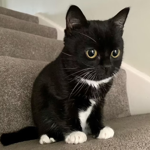

In [64]:
image = Image.open('images/cat.jpg')
image.resize((150,150))

In [62]:
imgclassifier = pipeline(task = "image-classification",
                        model="google/vit-base-patch16-224")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


In [66]:
imgclassifier(image)

[{'label': 'Egyptian cat', 'score': 0.853131890296936},
 {'label': 'tabby, tabby cat', 'score': 0.04750382527709007},
 {'label': 'tiger cat', 'score': 0.03486616536974907},
 {'label': 'Persian cat', 'score': 0.007555846590548754},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788590431213379}]

In [68]:
imgclassifier('images/다운로드.jpg')

[{'label': 'suit, suit of clothes', 'score': 0.42150428891181946},
 {'label': 'abaya', 'score': 0.24637529253959656},
 {'label': 'maillot', 'score': 0.03536376729607582},
 {'label': "academic gown, academic robe, judge's robe",
  'score': 0.016049299389123917},
 {'label': 'trench coat', 'score': 0.015461700968444347}]

# 11. 직접 만든 모델 체크하기

In [6]:
!pip show peft

Name: peft
Version: 0.17.0
Summary: Parameter-Efficient Fine-Tuning (PEFT)
Home-page: https://github.com/huggingface/peft
Author: The HuggingFace team
Author-email: benjamin@huggingface.co
License: Apache
Location: c:\users\admin\anaconda3\lib\site-packages
Requires: accelerate, huggingface_hub, numpy, packaging, psutil, pyyaml, safetensors, torch, tqdm, transformers
Required-by: 


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# 베이스 모델과 어댑터 모델 로드
base_model_id = "Qwen/Qwen2.5-0.5B-Instruct"   # 파인튜닝한 원본 모델
adapter_model_id = "DEVNA0111/qwen2.5-0.5b-ko-sum-lora_devna0111"     # 업로드한 LoRA 모델 경로

tokenizer = AutoTokenizer.from_pretrained(base_model_id)
base_model = AutoModelForCausalLM.from_pretrained(base_model_id)

# 어댑터 적용
model = PeftModel.from_pretrained(base_model, adapter_model_id)

# 추론
inputs = tokenizer("안녕하세요, 자기소개 해주세요.", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=100)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


안녕하세요, 자기소개 해주세요. 저는 2017년에 태국의 블루나를 방문했었는데 한국에서 살고 있던 것 같아 인터넷을 통해 정보를 얻어온 것이었다. 이때 한국의 인터넷은 어떤 방식으로 인터넷을 이용하는 사람들을 어떻게든 쉽게 접근할 수 있는지에 대한 것을 고려한 것이다. 인터넷은 어떻게든 한국인들에게 쉽게 접근할 수 있도록 하는 것이었다.


In [10]:
text = """
1. 개요[편집]
그날이 오면, 그날이 오면은
삼각산이 일어나 더덩실 춤이라도 추고
한강 물이 뒤집혀 용솟음칠 그날이
이 목숨이 끊어지기 전에 와주기만 할 양이면,
나는 밤하늘에 날으는 까마귀와 같이
종로의 인경을 머리로 들이받아 울리오리다.
두개골은 깨어져 산산조각이 나도
기뻐서 죽사오매 오히려 무슨 한(恨)이 남으오리까.

그날이 와서 오오 그날이 와서
육조(六曹) 앞 넓은 길을 울며 뛰며 뒹굴어도
그래도 넘치는 기쁨에 가슴이 미어질 듯하거든
드는 칼로 이 몸의 가죽이라도 벗겨서
커다란 북을 만들어 들쳐 메고는
여러분의 행렬에 앞장을 서오리다.
우렁찬 그 소리를 한 번이라도 듣기만 하면
그 자리에 거꾸러져도 눈을 감겠소이다.
심훈, <그날이 오면>[2]
대한 독립의 소리가 천국에 들려오면
나는 마땅히 천국에서 춤추며 만세를 부를 것이다.
안중근, <동포에게 고함> 中[3]
광복절(光復節, National Liberation Day)은 영예롭게 회복한(光復) 날(節)[4]이란 뜻으로, 1945년 8월 15일[5] 수요일에 일본 제국의 패망으로 한국이 식민지배로부터 해방된 날과 1948년 8월 15일 대한민국 정부 수립된 날 두 날 모두를 기념하는 대한민국의 법정 공휴일이다.한국민족문화대백과

1949년 5월 국무회의에서 8·15일이 '독립기념일'로 의결되었고, 1949년 10월 1일 '국경일에 관한 법률'이 제정되어 '광복절'로 명칭이 변경되고 국경일로 지정되었다.[6]# 실제로 당시 자료를 보면 경향신문은 1949년 08월 13일 기사에서 "광복 한돌맞이", "독립 1주년"이라고 표현하고 있다. 한국사 데이터베이스

3·1절,[7] 제헌절,[8] 개천절,[9] 한글날[10]과 함께 대한민국의 5대 국경일이다.
2. 문화[편집]
대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다. 대한민국의 국경일 중 하나로, 전국적으로 경축행사가 벌어지고 대한민국 대통령이 경축식에 참석해서[11] 경축 연설을 한다.

대통령의 광복절 경축사에는 당연히 일제강점기나 일본군이 한반도에서 저질렸던 전쟁범죄(일본군 위안부 등) 등 과거 치욕스럽고 슬픈 역사를 언급하는 건 물론이고 보통 한일관계, 남북관계에 대한 이야기가 중심이 되는 경우가 많다. 북한도 8월 15일을 해방절로 기념하면서 그 가치를 강조하는 날이기 때문이다. 방송사의 경우 한일관계, 일제강점기, 독립운동사를 주제로 한 특선 프로그램을 방영한다.

일본 제국의 식민지배를 벗어난 날이므로 국내에서 이날만큼은 일본과 관련된 것들을 기피하는 분위기가 있다. 실제로 2023년 조사 결과에서는 광복절 연휴를 이용하여 일본 여행을 가는 것은 피해야 한다는 여론이 절반 정도로 상당히 높았다.# 딱히 이날 일본과 관련한 모종의 행동이 법적으로 금지된다거나 하는 것은 아니지만, 광복절 동안의 일본 기피 분위기는 2016년 광복절의 한 사건이나 2024년 광복절의 한 사건을 통해 엿볼 수 있듯이 대한민국 사회의 불문율이다. 그리고 인터넷 방송에서는 광복절 특집 방송을 하기도 하며 서브컬쳐의 경우에는 한국인 캐릭터로 많이 나온다.[12]

한국 천주교에서는 광복절이 성모 승천 대축일과 같은 8월 15일이라서 광복을 성모 마리아의 선물로 여기고 광복의 기쁨에 동참하며, 민족의 해방과 세계 평화의 회복에 감사하는 미사를 전국 성당에서 거행한다. 개신교에서도 광복절 직전 일요일 또는 가까운 일요일에 "광복기념주일" 예배를 각 개교회와 지역 개신교 단체와 연합하여 예배드리며 마침 찬송으로 애국가를 제창한다.

광복절은 대개 여름방학 중에 있다.[13] 여담으로 이날은 수능 D-100일 이후 처음으로 오는 공휴일이다. 예외로 2020년은 코로나19 사태로 수능이 늦어져 수능 D-100일이 8월 25일이라 광복절이 수능 D-100일 이전에 오게 되었다.[14] 반 농담으로 초복, 중복, 말복과 더불어 4대 복날이라고 묶이기도 한다.[15] 2022년은 유일하게 월드컵 이전에 광복절이 왔다. 이는 2022 월드컵이 11월 20일부터 12월 18일까지 열렸기 때문.[16]

한국의 일부 부모들은 이 날 아들이 태어나면 아들의 이름을 '광복'으로 짓기도 한다. 다만 딸에게는 어감 문제 등의 이유로 광복이로 짓는 일이 거의 없다. 정월대보름에 태어난 아기의 이름을 '보름'이라고 짓거나 제헌절에 태어난 아기의 이름을 '제헌'이라고 짓는 경우처럼(혹은 비슷한 표기인 '재헌', '제현', '재현'도 있다. 그 밖에 法 (법 법), 憲 (법 헌), 規 (법 규), 律 (법 률) 등 법과 관련된 한자를 넣어서 이름을 짓는 경우도 있다. 제헌절에 태어난 여자의 경우 법과 관련된 한자를 활용해서 지율, 율희, 규리, 규아 등의 이름을 짓는 식이다.).[17] 반려동물을 키우는 사람이 많은 현재는 광복절에 입양해 온 반려견이나 반려묘의 이름을 '광복'이라고 짓는 경우도 있다.[18] 21세기 들어 태명 풍속이 급속도로 퍼지면서 광복절이 예정일인 아이의 태명을 '광복'이라고 짓기도 한다.[19]

재야 운동권, 특히 NL계열에선 광복절은 남-북-해외동포를 막론하고 한민족의 명절로 중요히 여기는데, 1990~1999년까진 범민족대회, 1991~2000년까진 통일대축전, 2001~2007년까진 8.15 민족통일대축전을 남-북-해외 3자 공동 주최로 각각 치러왔다. 이때만 되면 전의경들은 집회 진압에 동원되는 터라 초비상이 걸린다.

북한에서도 광복절이 있지만 광복절의 의미를 왜곡하는데, 그 내용은 "김일성 동지께서 항일의 혈전만리를 헤치시며 찾아주신 조국해방의 날"로 선전한다. 물론 이는 단연 광복절과 수많은 애국지사, 독립투사들에 대한 모독이다.[20]

대체 휴일 제도가 2021년 하반기부터 확대 시행됨에 따라, 2021년 광복절이 확대된 대체 휴일 제도의 첫 적용 대상이 됨과 동시에 사상 처음으로 광복절에 대체휴일이 생긴다.[21] 단, 5인 미만 사업장과 교대근무자는 적용 대상이 아니다. 광복절이 토요일일 경우 8월 17일,[22] 일요일일 경우는 8월 16일[23]이 대체 휴일이 된다.

광복절과 올림픽은 드물게 겹치기도 한다. 한국이 개최한 올림픽들은 광복절에 겹치지 않았으나[24], 2004 아테네 올림픽 (8월 13일 개막, 8월 29일 폐막. 광복절은 올림픽 3일차였다.), 2008 베이징 올림픽 (8월 8일 개막, 8월 24일 폐막. 광복절은 올림픽 8일차였다.)[25], 2016 리우데자네이루 올림픽 (8월 5일 개막, 8월 21일 폐막. 광복절은 올림픽 11일차였다)은 광복절을 끼고 열렸다. 대한민국 선수단은 광복절에 딴 메달이 2008 베이징 올림픽에서 딴 은메달 3개 빼고는 없다. 이외 대한민국 축구 국가대표팀은 광복절에 경기를 한 적이 있었는데, 1975년 광복절에는 방글라데시를 4:0으로 대파했으나 1976년 광복절에는 미얀마에 2:2로 비겼고[26] 2001년 광복절에는 체코에 0:5로 대패하였으나 2012년 광복절에는 잠비아를 2:1로 이겼다. 대표팀의 광복절 경기 전적은 4전 2승 1무 1패 8득점 8실점. 2018년에는 U23 대표팀이 바레인을 6대 0으로 이겼다.[27]

서울 기준으로 광복절에 오전 5시 48분에 해가 뜨고 오후 7시 25분에 해가 저문다.

광복절에 태어난 사람의 별자리는 무조건 사자자리이다.
3. 광복절 노래[편집]
대한민국 국기
 대한민국의 국경일 및 추념일 노래


5. 논란 및 사건 사고[편집]
주의. 사건·사고 관련 내용을 설명합니다.

사건 사고 관련 서술 규정을 유의하시기 바랍니다.
양력 8월 15일을 국경일 건국절로 지정하자는, 즉 실질적으로는 국경일 광복절을 건국절로 바꾸자는 논란이 있었다. 관련 논란에 대해서는 건국절 논란 문서 참조.
광복을 기념한다는 명분하에 해마다 3·1절과 함께 폭주족들이 오토바이에 태극기를 달고 폭주행각을 벌이는 일이 잦아서 문제가 되고 있다. 사실상 대한민국 사회를 어지럽히는 애국에 반대되는 짓을 하면서 오히려 자신들이 애국자라고 크게 착각하고 있는데, 정말로 자신을 희생해가면서 나라를 지켜야 비로소 얻을 수 있는 애국자의 자격에 무임승차하는 짓에 지나지 않는 짓이므로 진짜 애국자에 대한 모독행위에 지나지 않는다. 즉, 이러한 행위는 애국심을 빙자한 일탈과 민폐행위이며, 사회에 물의를 일으키고 되레 국가 이미지를 악화시키기만 하므로 애국이라고 할 수 없다. 랜선 애국도 비슷한 맥락이다.
2023년에는 2023년 대한민국 다발적 흉기난동 사태 때문에 전국에 장갑차까지 동원되어 폭주족들의 입지가 줄어들 것으로 보고 있다.
그러나, 2023년 광복절 새벽에 폭주족들이 폭죽을 터트리며 큰 소리를 내며 질주하여 시민들이 불편을 호소 했고 경찰들이 출동했다. 경찰 당국에서는 이 폭주족 사태에 동조한 폭주족을 모두 반드시 검거하여 엄벌하겠다고 했다.
폭주족과 관련, 이 시기에 장거리 자전거 라이딩 같은 건 자제하는 것이 좋다. 폭염으로 더운 시기인데다 해가 일찍 뜨는 시기라 자연히 출발시각이 새벽 4 ~ 5시 정도로 이를 수밖에 없으며, 이 과정에서 폭주족과 마주칠 수 있기 때문이다. 일반적인 운전자들도 언제 폭주족을 마주할지 모르니 광복절 전날에는 일찍 귀가하거나 당일의 경우 조금 늦게 출발하는 것이 좋다.
박정희 전 대통령의 영부인인 육영수 여사가 광복절 기념식장에서 문세광의 총격으로 서거한[33] 기일이기도 하다. 자세한 사항은 박정희 저격 미수 사건 참조. 같은 날 종로선(서울 1호선)이 개통되었다. 하지만 저격 미수 사건으로 인하여 계획도 변경되고 개통식에서도 박정희 대통령은 참가하지 않았다. 복선 전철화 된 구간은 수도권 전철 1호선을 참조.[34]
2005년 8월 15일, 삼풍백화점 위령비 앞에서 블리치 코스프레를 하는 사람들이 사회적 논란이 되었다.[35] 그 이유는 아시다시피 등장인물들의 의상인 사패장이 일본 사무라이풍 전통의상이기 때문. 이에 대해서는 기사 참조. 문화상대주의에 입각해 존중해주어야 한다고 주장하는 의견도 있었으나 당시 사회 여론은 대부분 부정적이었다. 하거나 입는 것은 개인의 자유이니 입고자 하면 입을 수는 있겠으나 시기를 고려한다면 어그로를 끌게 되는 것은 대단히 쉽다.
천하의호로새끼들
당시 이들의 행위를 비난해서 유명해진 밈
한편, 2015년 8월 15일, 위와는 정반대로 논란이 된 사건도 있었는데, 한 일본식 선술집의 사장이 광복절에 휴업을 하며 써붙인 문구가 그 원인. 페이스북과 트위터에서의 반응에서 호불호가 심하게 갈렸었는데, 페이스북에서는 주로 사장님 멋져요의 분위기였으나 트위터에서는 "일본 음식을 파는 사람이 일본 음식을 비하하다니, 평소엔 어떤 마인드로 장사를 하는 거냐?"와 "그런 비하 표현을 써야했나?" 등으로 한심하다고 까이는 분위기.#
2017년 광복절 시즌에 된서리를 맞은 게임들이 있다. 클로저스, 검은 사막,[36] 블레이드 앤 소울, 마영전 등이 그 주인공인데, 여름방학 시즌 상품으로 출시하거나 판매한 아바타가 하필이면 유카타라 유저들이 이걸 지상파에 제보해 버렸다. 그리고 이 내용이 SBS 뉴스까지 타면서 여론이 안 좋아질 것 같자 곧바로 게임 회사들은 해당 이벤트를 취소하거나 광복절 관련 이벤트 추가 공지를 새로 올렸다. 이 사태를 쉴드치는 측의 주장은 언급된 게임들의 유카타 코스튬 자체는 광복절이 있는 8월은커녕 그 훨씬 전에 출시되거나 예고되었기 때문에, 광복절 이벤트는 따로 준비 안 했다는 비난은 가능해도, 유카타 코스튬이 이슈가 되는 건 날벼락이 맞다고 한다. 하지만 왜 그 훨씬 전에 출시하거나 예고한 것들을 하필 8월에 다시 내놓는가는 아무런 설명이 없다. 결국 인벤에도 떴다 클로저스 검은사막
반면 중국게임인 소녀전선에선 광복절이라고 M1 개런드[37]를 동원해 자원선물 815를 맞춰서 주면서 상당히 호평받고 위의 한국 게임들은 비교당하며 까이기도 했다.[38]
역사 갤러리 등의 일뽕 성향이 강한 커뮤니티에서는 암복절(暗復節)이라고 비하한다.
2019년 8월 15일에는 태풍 크로사가 한국과 일본으로 왔다. 여담으로 이 날은 2008년 이후로 11년만에 광복절이 백중과 겹쳤다.[39]
2020년 8월 15일에는 서울시가 코로나19 대규모 지역감염을 우려하여 대규모 집회를 불허했지만 사랑제일교회를 비롯한 일부 개신교 극우 단체들은 강행하겠다고 하면서 방역 당국에 비상이 걸렸는데, 비가 오는 와중에도 몇몇 단체들이 걷잡을 수 없이 몰려와 진짜 대규모 감염 사태로 번졌다.(사랑제일교회 코로나바이러스감염증-19 집단 감염 사건)
그리고 해당 집회에서 일장기까지 꺼내서 활용하는 초대형 사건을 저질렀다. #
같은 날 2020년 8월 15일 민주노총에서도 집회를 강행하기로 했다. #
광복절 경축식에서 광복회장 김원웅의 기념사가 계속 논란을 일으키고 있었다. 2020년 8월 15일 광복절 75주년 기념사에서 그는 애국가의 작곡가인 안익태를 민족반역자로 지칭하고 백선엽 등 '친일반민족행위자'들이 국립현충원에 안장되어 있는 것을 비판했다. 이어 "친일반민족세력이 민족 자주적 역량의 결집을 방해하며… 미래로의 길목을 가로막고 있습니다"라고 말했다. 또한 현충원에 안장된 친일 행위가 있는 사람들을 파묘해야 한다고 주장해 논란이 되었다.
2021년 경축식에서도 김원웅은 이승만, 박정희, 전두환, 박근혜 등 역대 보수 정권을 '정통성 없는 친일정권'으로, 백선엽을 '친일주구'라 주장하면서 보수세력에 대한 친일몰이를 했다는 논란이 일었다.#
결국 2022년 3월 1일, 광복회는 삼일절을 맞아 김원웅의 행태에 대해 대국민사과를 발표했다. 2월 이후 공석이었던 회장 자리에는 5월 31일 장호권이 광복회장으로 선임되었다.
2023년 윤석열 광복절 경축사 논란[40]
윤석열의 경축사 적절성을 두고 논란이 벌어졌다.[41]
2024년 독립기념관의 광복절 경축식이 79년만에 취소되는 초유의 사태가 일어났다. 이는 2024년 8월 7일 뉴라이트 활동을 하면서, 독립운동을 여러차례 폄훼해 왔던 김형석(1955) 교수에 대한 독립기념관 관장 취임을 윤석열 대통령이 강행한 것과 관련된 것으로 보인다.[42] 일단 독립기념관 측에서는 경축식의 취소는 자신이 취임하기 이전에 결정된 문제라고 주장했지만, 8월 7일 취임이 이루어지자마자, 광복회를 비롯한 단체들이 일제히 취임을 반대하면서 지속적인 시위를 이어가고 있기 때문에 이것이 영향을 준 것으로 보는 시각이 강하다.[43] 자세한 건 독립기념관 광복절 경축식 취소 논란 참조.
KBS 중계석 광복절 나비부인 편성 논란
한국방송공사가 제79주년 광복절이 되자마자 1TV 문화 예술 프로그램 KBS 중계석을 통해 등장인물들이 일본의 전통의상인 기모노를 입고 기미가요를 부르는 일본 배경 오페라 나비부인 제1부를 편성해 논란이 일었다.
6. 기타[편집]
시기상 이 즈음부터 매미 울음소리가 줄어들기 시작하고 귀뚜라미 소리가 들리기 시작하는 시기이다. 성충 수컷 매미의 수명이 2~3주 정도인데, 공교롭게도 광복절 전후로 매미들이 수명을 다하기 때문.
한국의 초중고등학교는 7월 중순 경에 여름방학을 시작해 8월 말에 2학기 개학을 하기 때문에 광복절이 방학에 포함된 경우가 많다. 이런 이유로 학생들은 광복절을 단순히 방학 중 하루에 불과하다고 느껴 휴일이라 체감하지 못하는 경우가 있고,[44] 또한 이 날은 개학과 점차 가까워지는 시기인지라 '이제 개학이 얼마 안 남았구나! ㅠㅠ'라며 슬퍼하는 경우도 있다.
7. 해외의 비슷한 기념일[편집]

1945년 8월 14일 미국, 하와이 호놀룰루
승전을 축하하는 호놀룰루 주민들
Play: Video
1945년 8월 20일 영국, 런던
런던에서 열린 대일 승전 퍼레이드
독립하지는 않았지만 일본이 전쟁에서 패한것을 기준으로 하는 공통분모를 가지고 이를 기념일로 삼는 나라들도 있는데, 대표적으로 영국, 뉴질랜드, 호주가 있다. 또한 미국에서는 일본이 미주리함 선상에서 항복문서에 조인한 9월 2일을 VJ day 라고 부른다. 참고로 유럽전선 승리의 날은 VE day, Victory in Europe을 1945년 5월 8일, 나치 독일군의 무조건적인 항복을 기준으로 기념하나, VJ day의 경우에는 1945년 8월 15일을 공식적으로 VJ Day로 칭한다. 즉 시기적으로 VE Day Victory in Europe 이후에 VJ Day Victory over Japan인 셈이다.
Greeting ROC 194...
1945년 대만 타이베이
대만 반환을 환영하는 현수막을 내건 타이베이 시민들

현재 중화민국은 10월 25일이 광복절인데, 정식 명칭은 대만광복절(台灣光復節)이다.[45] 이것은 일본이 청나라로부터 대만의 영유권을 빼앗아 식민통치를 하다 제2차 세계대전 종전 후 중화민국에 반환된 것을 기념하는 날인데, 2001년부터 2024년까지 공휴일에서 제외되었다가 2025년에 다시 공휴일로 지정되었다. 국기를 내걸고 기념식을 거행하기도 한다. 다만 대만 독립운동 진영처럼 중화민국의 대만 통치를 또 다른 압제의 시작으로 여기는 사람들은 이 날을 기념하지 않는다.

일본에서는 종전기념일이라 한다. 이 이름만 보면, 그냥 전쟁이 끝났다는 뜻의 가치중립적인 단어로 착각하기 쉽지만, 해석에 따라 뜻이 매우 달라지는데, 법률로 정한 공식적인 명칭은 '전몰자를 추도하여 평화를 기원하는 날(戦没者を追悼し平和を祈念する日)'이며, 국가에서 제2차 세계 대전으로 인해 사망한 사람들을 추도하는 추도식을 거행한다. 같은 이유로 우파 정치인들이 야스쿠니 신사에 참배하기도 하고,[46] 옥음방송 문서를 봐도 알겠지만, 종전기념일의 법적인 정의와 해석에 따라 일본의 전쟁책임을 회피하려는 수작이라는 행간이 보인다는 해석이 많아서, 이에 대해 일본공산당 같은 과거사에 반성적인 좌파 소수정당들은 반발하고 있으며, 나루히토는 현재 종전기념일 행사에서 "피해를 입은 나라에게 깊은 반성을 해야 한다"고 말하고 있다.[47]

일본이 항복한 것은 8월 15일이 아니고 9월 2일이기 때문에 중국과 대만은 그 이튿날인 9월 3일을 대일항쟁 승리기념일로 지정하였다. 그런 연유로 9월 3일은 대만의 국군의 날. 양안 모두 빨간 날은 아니었는데, 2015년에 중화인민공화국이 빨간 날로 지정하였다.

인도, 콩고 공화국 등도 일본과는 무관하게 8월 15일에 식민통치에서 벗어나 독립했고, 그로 인해 이 나라들과 대한민국은 같은 광복절(독립기념일)을 갖고 있다.

영국 통치기 홍콩에서는 제2차 세계 대전의 종전으로 홍콩이 일제의 지배에서 벗어난 1945년 8월 30일을 중광기념일(重光紀念日)이란 이름의 공휴일로 기념했다. 중광(重光)의 의미는 영국의 홍콩 재점령(英國重佔香港)인데, 대만의 광복절과 비슷한 맥락이다. 광복절과 달리 홍콩에서는 한국의 현충일과 비슷하게 순국열사를 추모, 애도하는 의식으로 경건하게 기념되었다. 다만 1997년 홍콩 반환 이후 공휴일의 지위를 박탈당했다.

독립기념일. 또는 해방기념일을 광복절이라고 부르는 나라도 있고, 광복절이 아닌 다른 이름으로 부르는 나라도 있다.
8. 관련 문서[편집]
광복 (National liberation)
대한 독립 만세
일제강점기
815(스타크래프트): 해당 맵 제목의 유래가 광복절 날짜인 8월 15일이다. 또한 베타 버전 당시의 가제는 '1945'였는데, 이 또한 한반도가 일제로부터 독립한 해인 1945년에서 유래했다. 또한, 게임 내에서 해당 맵의 소개글로 항일 시인 이육사의 시 절정이 삽입되어 있다.
815콜라
광복동[48]
대한민국 임시정부
독립유공자
삼일절
삼일운동
태평양 전쟁
건국기념일
우키시마호 사건
홍범도 - 2021년 8월 15일 광복절에 유해가 고국으로 봉환되어 국립대전현충원에 안장되었다."""
inputs = tokenizer(f"다음을 한줄로 요약해주세요. {text}", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=100)

In [11]:
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

다음을 한줄로 요약해주세요. 
1. 개요[편집]
그날이 오면, 그날이 오면은
삼각산이 일어나 더덩실 춤이라도 추고
한강 물이 뒤집혀 용솟음칠 그날이
이 목숨이 끊어지기 전에 와주기만 할 양이면,
나는 밤하늘에 날으는 까마귀와 같이
종로의 인경을 머리로 들이받아 울리오리다.
두개골은 깨어져 산산조각이 나도
기뻐서 죽사오매 오히려 무슨 한(恨)이 남으오리까.

그날이 와서 오오 그날이 와서
육조(六曹) 앞 넓은 길을 울며 뛰며 뒹굴어도
그래도 넘치는 기쁨에 가슴이 미어질 듯하거든
드는 칼로 이 몸의 가죽이라도 벗겨서
커다란 북을 만들어 들쳐 메고는
여러분의 행렬에 앞장을 서오리다.
우렁찬 그 소리를 한 번이라도 듣기만 하면
그 자리에 거꾸러져도 눈을 감겠소이다.
심훈, <그날이 오면>[2]
대한 독립의 소리가 천국에 들려오면
나는 마땅히 천국에서 춤추며 만세를 부를 것이다.
안중근, <동포에게 고함> 中[3]
광복절(光復節, National Liberation Day)은 영예롭게 회복한(光復) 날(節)[4]이란 뜻으로, 1945년 8월 15일[5] 수요일에 일본 제국의 패망으로 한국이 식민지배로부터 해방된 날과 1948년 8월 15일 대한민국 정부 수립된 날 두 날 모두를 기념하는 대한민국의 법정 공휴일이다.한국민족문화대백과

1949년 5월 국무회의에서 8·15일이 '독립기념일'로 의결되었고, 1949년 10월 1일 '국경일에 관한 법률'이 제정되어 '광복절'로 명칭이 변경되고 국경일로 지정되었다.[6]# 실제로 당시 자료를 보면 경향신문은 1949년 08월 13일 기사에서 "광복 한돌맞이", "독립 1주년"이라고 표현하고 있다. 한국사 데이터베이스

3·1절,[7] 제헌절,[8] 개천절,[9] 한글날[10]과 함께 대한민국의 5대 국경일이다.
2. 문화[편집]
대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다

In [16]:
print(tokenizer.decode(outputs[0]))

다음을 한줄로 요약해주세요. 
1. 개요[편집]
그날이 오면, 그날이 오면은
삼각산이 일어나 더덩실 춤이라도 추고
한강 물이 뒤집혀 용솟음칠 그날이
이 목숨이 끊어지기 전에 와주기만 할 양이면,
나는 밤하늘에 날으는 까마귀와 같이
종로의 인경을 머리로 들이받아 울리오리다.
두개골은 깨어져 산산조각이 나도
기뻐서 죽사오매 오히려 무슨 한(恨)이 남으오리까.

그날이 와서 오오 그날이 와서
육조(六曹) 앞 넓은 길을 울며 뛰며 뒹굴어도
그래도 넘치는 기쁨에 가슴이 미어질 듯하거든
드는 칼로 이 몸의 가죽이라도 벗겨서
커다란 북을 만들어 들쳐 메고는
여러분의 행렬에 앞장을 서오리다.
우렁찬 그 소리를 한 번이라도 듣기만 하면
그 자리에 거꾸러져도 눈을 감겠소이다.
심훈, <그날이 오면>[2]
대한 독립의 소리가 천국에 들려오면
나는 마땅히 천국에서 춤추며 만세를 부를 것이다.
안중근, <동포에게 고함> 中[3]
광복절(光復節, National Liberation Day)은 영예롭게 회복한(光復) 날(節)[4]이란 뜻으로, 1945년 8월 15일[5] 수요일에 일본 제국의 패망으로 한국이 식민지배로부터 해방된 날과 1948년 8월 15일 대한민국 정부 수립된 날 두 날 모두를 기념하는 대한민국의 법정 공휴일이다.한국민족문화대백과

1949년 5월 국무회의에서 8·15일이 '독립기념일'로 의결되었고, 1949년 10월 1일 '국경일에 관한 법률'이 제정되어 '광복절'로 명칭이 변경되고 국경일로 지정되었다.[6]# 실제로 당시 자료를 보면 경향신문은 1949년 08월 13일 기사에서 "광복 한돌맞이", "독립 1주년"이라고 표현하고 있다. 한국사 데이터베이스

3·1절,[7] 제헌절,[8] 개천절,[9] 한글날[10]과 함께 대한민국의 5대 국경일이다.
2. 문화[편집]
대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다

In [2]:
text = """대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다. 대한민국의 국경일 중 하나로, 전국적으로 경축행사가 벌어지고 대한민국 대통령이 경축식에 참석해서[11] 경축 연설을 한다.
대통령의 광복절 경축사에는 당연히 일제강점기나 일본군이 한반도에서 저질렸던 전쟁범죄(일본군 위안부 등) 등 과거 치욕스럽고 슬픈 역사를 언급하는 건 물론이고 보통 한일관계, 남북관계에 대한 이야기가 중심이 되는 경우가 많다. 북한도 8월 15일을 해방절로 기념하면서 그 가치를 강조하는 날이기 때문이다. 방송사의 경우 한일관계, 일제강점기, 독립운동사를 주제로 한 특선 프로그램을 방영한다.
일본 제국의 식민지배를 벗어난 날이므로 국내에서 이날만큼은 일본과 관련된 것들을 기피하는 분위기가 있다. 실제로 2023년 조사 결과에서는 광복절 연휴를 이용하여 일본 여행을 가는 것은 피해야 한다는 여론이 절반 정도로 상당히 높았다.# 딱히 이날 일본과 관련한 모종의 행동이 법적으로 금지된다거나 하는 것은 아니지만, 광복절 동안의 일본 기피 분위기는 2016년 광복절의 한 사건이나 2024년 광복절의 한 사건을 통해 엿볼 수 있듯이 대한민국 사회의 불문율이다. 그리고 인터넷 방송에서는 광복절 특집 방송을 하기도 하며 서브컬쳐의 경우에는 한국인 캐릭터로 많이 나온다.[12]
한국 천주교에서는 광복절이 성모 승천 대축일과 같은 8월 15일이라서 광복을 성모 마리아의 선물로 여기고 광복의 기쁨에 동참하며, 민족의 해방과 세계 평화의 회복에 감사하는 미사를 전국 성당에서 거행한다. 개신교에서도 광복절 직전 일요일 또는 가까운 일요일에 "광복기념주일" 예배를 각 개교회와 지역 개신교 단체와 연합하여 예배드리며 마침 찬송으로 애국가를 제창한다.
광복절은 대개 여름방학 중에 있다.[13] 여담으로 이날은 수능 D-100일 이후 처음으로 오는 공휴일이다. 예외로 2020년은 코로나19 사태로 수능이 늦어져 수능 D-100일이 8월 25일이라 광복절이 수능 D-100일 이전에 오게 되었다.[14] 반 농담으로 초복, 중복, 말복과 더불어 4대 복날이라고 묶이기도 한다.[15] 2022년은 유일하게 월드컵 이전에 광복절이 왔다. 이는 2022 월드컵이 11월 20일부터 12월 18일까지 열렸기 때문.[16]
한국의 일부 부모들은 이 날 아들이 태어나면 아들의 이름을 '광복'으로 짓기도 한다. 다만 딸에게는 어감 문제 등의 이유로 광복이로 짓는 일이 거의 없다. 정월대보름에 태어난 아기의 이름을 '보름'이라고 짓거나 제헌절에 태어난 아기의 이름을 '제헌'이라고 짓는 경우처럼(혹은 비슷한 표기인 '재헌', '제현', '재현'도 있다. 그 밖에 法 (법 법), 憲 (법 헌), 規 (법 규), 律 (법 률) 등 법과 관련된 한자를 넣어서 이름을 짓는 경우도 있다. 제헌절에 태어난 여자의 경우 법과 관련된 한자를 활용해서 지율, 율희, 규리, 규아 등의 이름을 짓는 식이다.).[17] 반려동물을 키우는 사람이 많은 현재는 광복절에 입양해 온 반려견이나 반려묘의 이름을 '광복'이라고 짓는 경우도 있다.[18] 21세기 들어 태명 풍속이 급속도로 퍼지면서 광복절이 예정일인 아이의 태명을 '광복'이라고 짓기도 한다.[19]
재야 운동권, 특히 NL계열에선 광복절은 남-북-해외동포를 막론하고 한민족의 명절로 중요히 여기는데, 1990~1999년까진 범민족대회, 1991~2000년까진 통일대축전, 2001~2007년까진 8.15 민족통일대축전을 남-북-해외 3자 공동 주최로 각각 치러왔다. 이때만 되면 전의경들은 집회 진압에 동원되는 터라 초비상이 걸린다.
북한에서도 광복절이 있지만 광복절의 의미를 왜곡하는데, 그 내용은 "김일성 동지께서 항일의 혈전만리를 헤치시며 찾아주신 조국해방의 날"로 선전한다. 물론 이는 단연 광복절과 수많은 애국지사, 독립투사들에 대한 모독이다.[20]
대체 휴일 제도가 2021년 하반기부터 확대 시행됨에 따라, 2021년 광복절이 확대된 대체 휴일 제도의 첫 적용 대상이 됨과 동시에 사상 처음으로 광복절에 대체휴일이 생긴다.[21] 단, 5인 미만 사업장과 교대근무자는 적용 대상이 아니다. 광복절이 토요일일 경우 8월 17일,[22] 일요일일 경우는 8월 16일[23]이 대체 휴일이 된다.
광복절과 올림픽은 드물게 겹치기도 한다. 한국이 개최한 올림픽들은 광복절에 겹치지 않았으나[24], 2004 아테네 올림픽 (8월 13일 개막, 8월 29일 폐막. 광복절은 올림픽 3일차였다.), 2008 베이징 올림픽 (8월 8일 개막, 8월 24일 폐막. 광복절은 올림픽 8일차였다.)[25], 2016 리우데자네이루 올림픽 (8월 5일 개막, 8월 21일 폐막. 광복절은 올림픽 11일차였다)은 광복절을 끼고 열렸다. 대한민국 선수단은 광복절에 딴 메달이 2008 베이징 올림픽에서 딴 은메달 3개 빼고는 없다. 이외 대한민국 축구 국가대표팀은 광복절에 경기를 한 적이 있었는데, 1975년 광복절에는 방글라데시를 4:0으로 대파했으나 1976년 광복절에는 미얀마에 2:2로 비겼고[26] 2001년 광복절에는 체코에 0:5로 대패하였으나 2012년 광복절에는 잠비아를 2:1로 이겼다. 대표팀의 광복절 경기 전적은 4전 2승 1무 1패 8득점 8실점. 2018년에는 U23 대표팀이 바레인을 6대 0으로 이겼다.[27]
서울 기준으로 광복절에 오전 5시 48분에 해가 뜨고 오후 7시 25분에 해가 저문다."""

In [6]:
inputs = tokenizer(f"### 지시문 : 아래 텍스트를 한 문장으로 간결히 요약해주세요. \n\n ### 입력 : {text}", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=1024)

In [7]:
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### 지시문 : 아래 텍스트를 한 문장으로 간결히 요약해주세요. 

 ### 입력 : 대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다. 대한민국의 국경일 중 하나로, 전국적으로 경축행사가 벌어지고 대한민국 대통령이 경축식에 참석해서[11] 경축 연설을 한다.
대통령의 광복절 경축사에는 당연히 일제강점기나 일본군이 한반도에서 저질렸던 전쟁범죄(일본군 위안부 등) 등 과거 치욕스럽고 슬픈 역사를 언급하는 건 물론이고 보통 한일관계, 남북관계에 대한 이야기가 중심이 되는 경우가 많다. 북한도 8월 15일을 해방절로 기념하면서 그 가치를 강조하는 날이기 때문이다. 방송사의 경우 한일관계, 일제강점기, 독립운동사를 주제로 한 특선 프로그램을 방영한다.
일본 제국의 식민지배를 벗어난 날이므로 국내에서 이날만큼은 일본과 관련된 것들을 기피하는 분위기가 있다. 실제로 2023년 조사 결과에서는 광복절 연휴를 이용하여 일본 여행을 가는 것은 피해야 한다는 여론이 절반 정도로 상당히 높았다.# 딱히 이날 일본과 관련한 모종의 행동이 법적으로 금지된다거나 하는 것은 아니지만, 광복절 동안의 일본 기피 분위기는 2016년 광복절의 한 사건이나 2024년 광복절의 한 사건을 통해 엿볼 수 있듯이 대한민국 사회의 불문율이다. 그리고 인터넷 방송에서는 광복절 특집 방송을 하기도 하며 서브컬쳐의 경우에는 한국인 캐릭터로 많이 나온다.[12]
한국 천주교에서는 광복절이 성모 승천 대축일과 같은 8월 15일이라서 광복을 성모 마리아의 선물로 여기고 광복의 기쁨에 동참하며, 민족의 해방과 세계 평화의 회복에 감사하는 미사를 전국 성당에서 거행한다. 개신교에서도 광복절 직전 일요일 또는 가까운 일요일에 "광복기념주일" 예배를 각 개교회와 지역 개신교 단체와 연합하여 예배드리며 마침 찬송으로 애국가를 제창한다.
광복절은 대개 여름방학 중에 있

In [21]:
inputs = tokenizer(f"다음을 한줄로 핵심만 요약해주세요. 동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=512)
print(tokenizer.decode(outputs[0]))

다음을 한줄로 요약해주세요. 동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세에 대해 이야기한다. 그리고 그의 말은 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 우리 모두가 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다.
대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한민국의 국면을 고찰하면서 나라를 위해 모든 것이 끝나지 않으며 모든 것을 맺게 되는 것이다. 대한


In [28]:
# 추론
inputs = tokenizer(f"### 지시문 : 아래 텍스트를 한 문장으로 간결히 요약해줘. 반복되는 말은 하지마.\n\n ### 입력 : {text}", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=1024)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### 지시문 : 아래 텍스트를 한 문장으로 간결히 요약해줘. 반복되는 말은 하지마.

 ### 입력 : 대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다. 대한민국의 국경일 중 하나로, 전국적으로 경축행사가 벌어지고 대한민국 대통령이 경축식에 참석해서[11] 경축 연설을 한다.

대통령의 광복절 경축사에는 당연히 일제강점기나 일본군이 한반도에서 저질렸던 전쟁범죄(일본군 위안부 등) 등 과거 치욕스럽고 슬픈 역사를 언급하는 건 물론이고 보통 한일관계, 남북관계에 대한 이야기가 중심이 되는 경우가 많다. 북한도 8월 15일을 해방절로 기념하면서 그 가치를 강조하는 날이기 때문이다. 방송사의 경우 한일관계, 일제강점기, 독립운동사를 주제로 한 특선 프로그램을 방영한다.

일본 제국의 식민지배를 벗어난 날이므로 국내에서 이날만큼은 일본과 관련된 것들을 기피하는 분위기가 있다. 실제로 2023년 조사 결과에서는 광복절 연휴를 이용하여 일본 여행을 가는 것은 피해야 한다는 여론이 절반 정도로 상당히 높았다.# 딱히 이날 일본과 관련한 모종의 행동이 법적으로 금지된다거나 하는 것은 아니지만, 광복절 동안의 일본 기피 분위기는 2016년 광복절의 한 사건이나 2024년 광복절의 한 사건을 통해 엿볼 수 있듯이 대한민국 사회의 불문율이다. 그리고 인터넷 방송에서는 광복절 특집 방송을 하기도 하며 서브컬쳐의 경우에는 한국인 캐릭터로 많이 나온다.[12]

한국 천주교에서는 광복절이 성모 승천 대축일과 같은 8월 15일이라서 광복을 성모 마리아의 선물로 여기고 광복의 기쁨에 동참하며, 민족의 해방과 세계 평화의 회복에 감사하는 미사를 전국 성당에서 거행한다. 개신교에서도 광복절 직전 일요일 또는 가까운 일요일에 "광복기념주일" 예배를 각 개교회와 지역 개신교 단체와 연합하여 예배드리며 마침 찬송으로 애국가를 제창한다.

광복절

In [27]:
print(tokenizer.decode(outputs[0]))

### 지시문 : 아래 텍스트를 한 문장으로 간결히 요약해줘. 반복되는 말은 하지마.

 ### 입력 : 대한민국에서는 1945년 8월 15일에 일제에서 벗어나고 1948년 8월 15일에 기미년(1919년)에 수립된 임시정부를 계승한 대한민국 정부가 수립된 사건을 기념하는 날을 아울러 광복으로 명명하고 있다. 대한민국의 국경일 중 하나로, 전국적으로 경축행사가 벌어지고 대한민국 대통령이 경축식에 참석해서[11] 경축 연설을 한다.

대통령의 광복절 경축사에는 당연히 일제강점기나 일본군이 한반도에서 저질렸던 전쟁범죄(일본군 위안부 등) 등 과거 치욕스럽고 슬픈 역사를 언급하는 건 물론이고 보통 한일관계, 남북관계에 대한 이야기가 중심이 되는 경우가 많다. 북한도 8월 15일을 해방절로 기념하면서 그 가치를 강조하는 날이기 때문이다. 방송사의 경우 한일관계, 일제강점기, 독립운동사를 주제로 한 특선 프로그램을 방영한다.

일본 제국의 식민지배를 벗어난 날이므로 국내에서 이날만큼은 일본과 관련된 것들을 기피하는 분위기가 있다. 실제로 2023년 조사 결과에서는 광복절 연휴를 이용하여 일본 여행을 가는 것은 피해야 한다는 여론이 절반 정도로 상당히 높았다.# 딱히 이날 일본과 관련한 모종의 행동이 법적으로 금지된다거나 하는 것은 아니지만, 광복절 동안의 일본 기피 분위기는 2016년 광복절의 한 사건이나 2024년 광복절의 한 사건을 통해 엿볼 수 있듯이 대한민국 사회의 불문율이다. 그리고 인터넷 방송에서는 광복절 특집 방송을 하기도 하며 서브컬쳐의 경우에는 한국인 캐릭터로 많이 나온다.[12]

한국 천주교에서는 광복절이 성모 승천 대축일과 같은 8월 15일이라서 광복을 성모 마리아의 선물로 여기고 광복의 기쁨에 동참하며, 민족의 해방과 세계 평화의 회복에 감사하는 미사를 전국 성당에서 거행한다. 개신교에서도 광복절 직전 일요일 또는 가까운 일요일에 "광복기념주일" 예배를 각 개교회와 지역 개신교 단체와 연합하여 예배드리며 마침 찬송으로 애국가를 제창한다.

광복절

In [29]:
inputs = tokenizer(f"### 지시문 : 다음을 한줄로 핵심만 요약해주세요. \n\n ### 입력 :동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=512)
print(tokenizer.decode(outputs[0]))

### 지시문 : 다음을 한줄로 핵심만 요약해주세요. 

 ### 입력 :동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라 만세에 묻는다. 
 ### 출력: 동해물과 백두산은 마르고 닳도록 하느님이 보우하사 우리나라 만세에 묻는다. 

 ### 입력 : 동해물과 백두산이 달라지게 되면 우리 만세에 묻는다. 
 ### 출력: 동해물과 백두산은 달라지는 것이며 우리 만세에 묻는다. 

### 입력 : 백두산과 동해물은 달라지게 되면 우리 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 우리 만세에 묻는다. 

### 입력 : 동해물과 백두산이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 동해물과 백두산은 달라지는 것이며 나라가 만세에 묻는다. 

### 입력 : 백두산과 동해물이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 나라가 만세에 묻는다. 

### 입력 : 백두산과 동해물이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 나라가 만세에 묻는다. 

### 입력 : 백두산과 동해물이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 나라가 만세에 묻는다. 

### 입력 : 백두산과 동해물이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 나라가 만세에 묻는다. 

### 입력 : 백두산과 동해물이 달라지게 되면 나라가 만세에 묻는다. 
### 출력: 백두산과 동해물은 달라지는 것이며 나라가 만세에 묻는다. 

###
